In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
data=pd.read_csv('healthcare_dataset.csv')

In [107]:
print('Shape:',data.shape)

Shape: (6000, 7)


In [108]:
data.columns

Index(['patient_id', 'age', 'bmi', 'exercise_hours_per_week', 'smoker',
       'blood_pressure', 'diabetes'],
      dtype='object')

In [109]:
print("Missing values:\n",data.isnull().sum())

Missing values:
 patient_id                 0
age                        0
bmi                        0
exercise_hours_per_week    0
smoker                     0
blood_pressure             0
diabetes                   0
dtype: int64


In [110]:
data.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


Text(0.5, 1.0, 'Age vs Dibates')

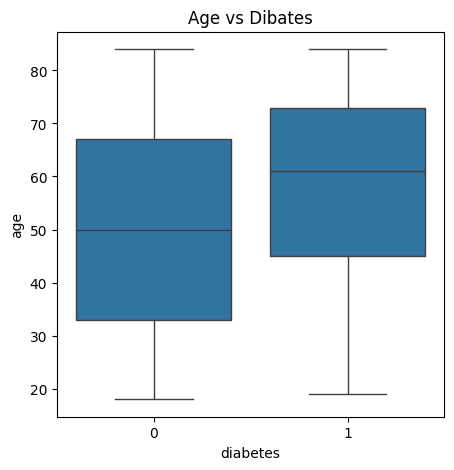

In [111]:
plt.figure(figsize=(5,5))
sns.boxplot(x='diabetes', y='age', data=data)
plt.title("Age vs Dibates")

Text(0.5, 1.0, 'BMI distribution')

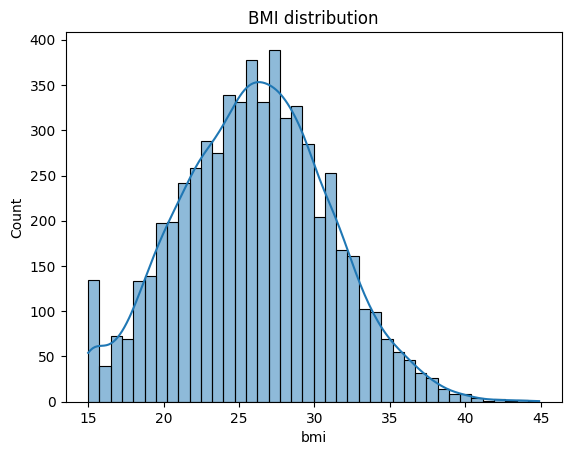

In [112]:
sns.histplot(data['bmi'],kde=True)
plt.title("BMI distribution")

Text(0.5, 1.0, 'Exercise vs Dibates')

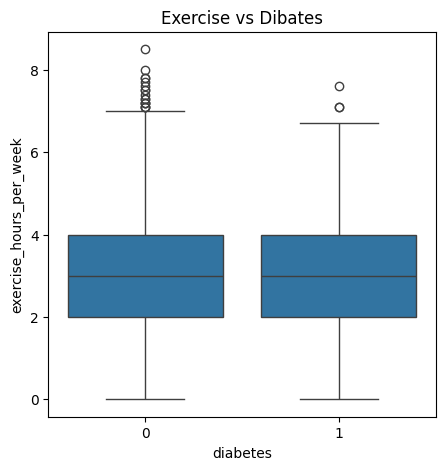

In [113]:
plt.figure(figsize=(5,5))
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=data)
plt.title("Exercise vs Dibates")

Text(0.5, 1.0, 'Correlation heatmap')

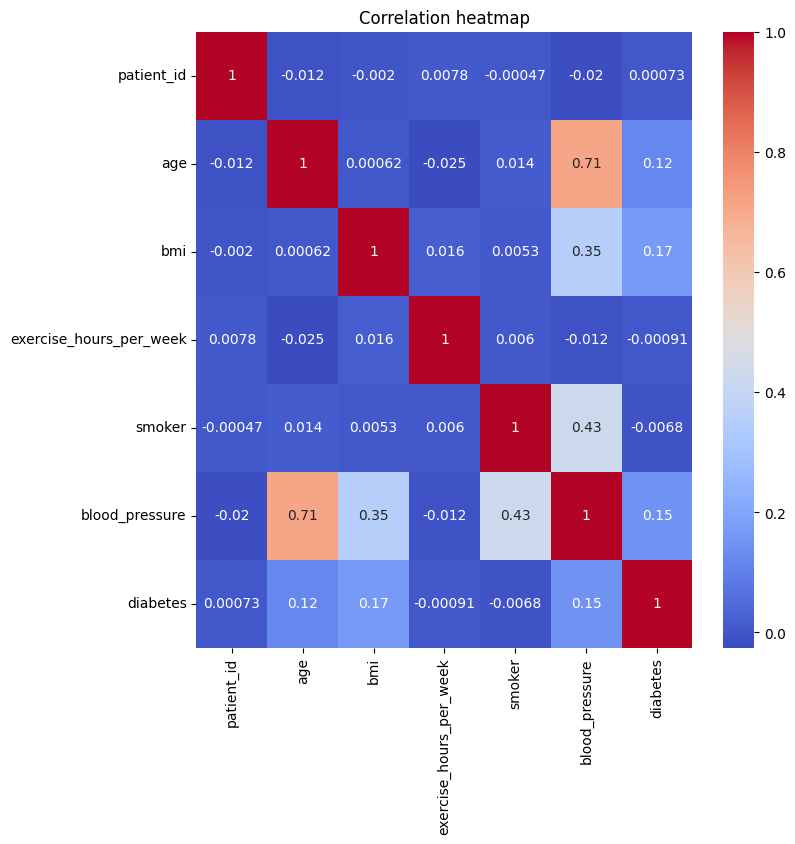

In [114]:
plt.figure(figsize=(8,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation heatmap")

## **Machine Learning Model**

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [116]:
data=data.drop("patient_id",axis=1)
X=data.drop("diabetes",axis=1)
y=data['diabetes']

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.70)

In [117]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [118]:
model=LogisticRegression(random_state=42, class_weight='balanced')
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

In [119]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification report:\n",classification_report(y_test,y_pred))

Accuracy: 0.6511111111111111
Confusion matrix:
 [[1073  568]
 [  60   99]]
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.65      0.77      1641
           1       0.15      0.62      0.24       159

    accuracy                           0.65      1800
   macro avg       0.55      0.64      0.51      1800
weighted avg       0.88      0.65      0.73      1800



## **Neural Network**

In [120]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [121]:
data=pd.read_csv('healthcare_dataset.csv')
data=data.drop('patient_id',axis=1)
X=data.drop("diabetes",axis=1)
y=data['diabetes']

X_train_nn,X_test_nn,y_train_nn,y_test_nn = train_test_split(X,y,train_size=0.70)

In [122]:
scaler=StandardScaler()
X_train_nn=scaler.fit_transform(X_train_nn)
X_test_nn=scaler.transform(X_test_nn)

In [146]:
model = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [147]:
model.compile(
    optimizer='adam',
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(),
        keras.metrics.MeanSquaredError()
    ]
)

In [148]:
class_weight = {
    0: 1,
    1: 9   # or higher
}
history=model.fit(X_train_nn,y_train_nn,epochs=15,validation_data=(X_test_nn,y_test_nn),class_weight=class_weight)

Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - binary_accuracy: 0.5445 - loss: 1.1548 - mean_squared_error: 0.2316 - val_binary_accuracy: 0.5944 - val_loss: 0.6163 - val_mean_squared_error: 0.2149
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5876 - loss: 1.1162 - mean_squared_error: 0.2168 - val_binary_accuracy: 0.5589 - val_loss: 0.6346 - val_mean_squared_error: 0.2245
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5676 - loss: 1.1004 - mean_squared_error: 0.2204 - val_binary_accuracy: 0.5850 - val_loss: 0.6055 - val_mean_squared_error: 0.2117
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5938 - loss: 1.0960 - mean_squared_error: 0.2111 - val_binary_accuracy: 0.5950 - val_loss: 0.6080 - val_mean_squared_error: 0.2127
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5867 - loss: 1.1126 - mean_squared_error: 0.2150 - val_binary_accuracy: 0.5778 - val_loss: 0.6246 - val_mean_sq

In [145]:
loss, accuracy, mean_squared_error = model.evaluate(X_test_nn, y_test_nn)
print("Neural Network Accuracy:", accuracy)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5394 - loss: 0.6415 - mean_squared_error: 0.2278
Neural Network Accuracy: 0.5394444465637207


In [127]:
y_prob_nn = model.predict(X_test_nn) # Use X_test_nn for prediction, as the model was trained on scaled data
y_pred_nn = (y_prob_nn > 0.5).astype(int) # Convert probabilities to binary predictions with a standard 0.5 threshold
print("Confusion matrix:\n",confusion_matrix(y_test_nn,y_pred_nn))
print("Classification report:\n",classification_report(y_test_nn,y_pred_nn))

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion matrix:
 [[953 693]
 [ 48 106]]
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.58      0.72      1646
           1       0.13      0.69      0.22       154

    accuracy                           0.59      1800
   macro avg       0.54      0.63      0.47      1800
weighted avg       0.88      0.59      0.68      1800



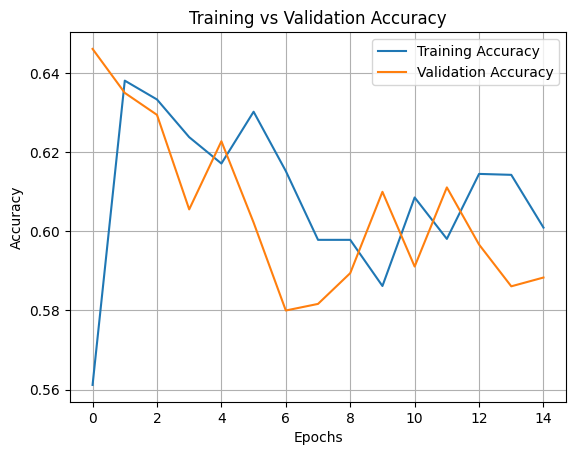

In [128]:
#Accuracy graph
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

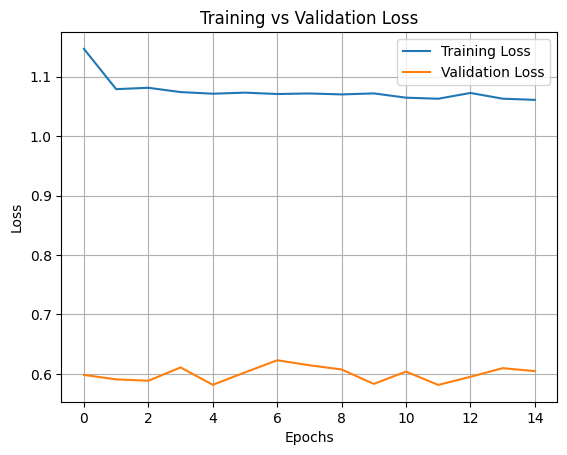

In [129]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

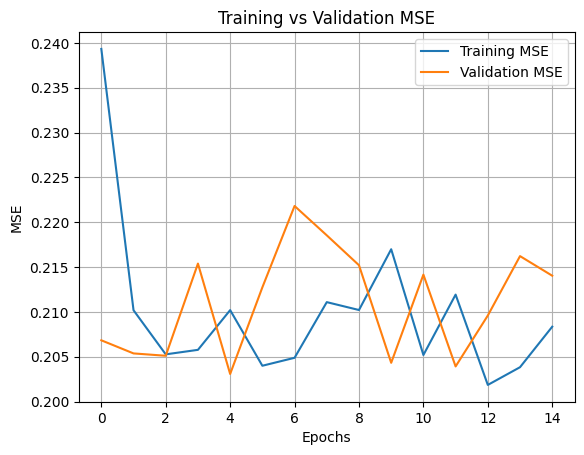

In [130]:
plt.figure()
plt.plot(history.history['mean_squared_error'], label='Training MSE')
plt.plot(history.history['val_mean_squared_error'], label='Validation MSE')

plt.title("Training vs Validation MSE")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid()

plt.show()